Silhouette Score (sample): 0.35192695567692456


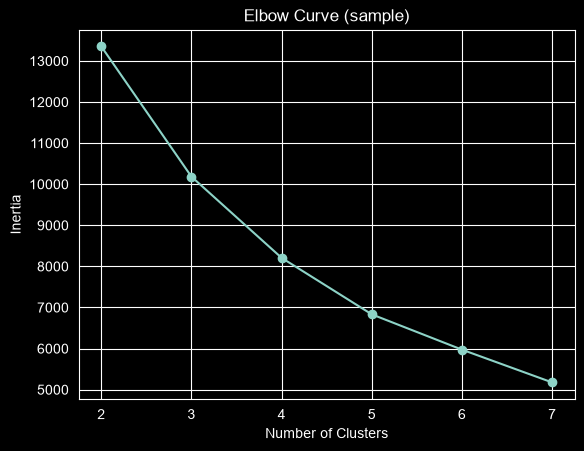

Cluster Purity (Urban ratio per cluster):
kmeans_cluster
0    1.0
1    1.0
2    1.0
3    1.0
Name: onor_policy, dtype: float64


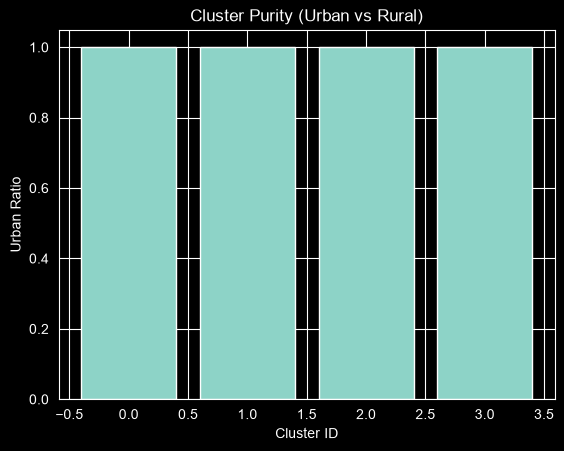

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# --- Load clustered dataset ---
df = pd.read_csv("C://Users//cxsha//PycharmProjects//Telangana_govt_ration_distribution_analysis//data//clustering_results_streaming_2.csv")

# --- Features (exclude cluster labels) ---
feature_cols = ['utilization_ratio','rice_wheat_ratio','trans_volatility',
                'lag_trans','rolling_mean_3m','onor_policy']

X = df[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Silhouette Score (sample for speed) ---
sample_idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
sil_score = silhouette_score(X_scaled[sample_idx], df["kmeans_cluster"].iloc[sample_idx])
print("Silhouette Score (sample):", sil_score)

# --- Elbow Curve (sample for speed) ---
inertia = []
K_range = range(2, 8)
X_sample = X_scaled[sample_idx]
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_sample)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Curve (sample)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# --- Cluster Purity (Urban vs Rural proxy) ---
purity_results = df.groupby("kmeans_cluster")["onor_policy"].mean()
print("Cluster Purity (Urban ratio per cluster):")
print(purity_results)

plt.bar(purity_results.index, purity_results.values)
plt.title("Cluster Purity (Urban vs Rural)")
plt.xlabel("Cluster ID")
plt.ylabel("Urban Ratio")
plt.show()